# Agent Reporting System — Deep Dive

This notebook demonstrates the three-agent reporting pipeline:

```
AOISummary
    ↓
run_researcher()  → 8 tool calls → findings dict + scratchpad
    ↓
run_writer()      → structured markdown report (7 sections)
    ↓
run_synthesist()  → cross-AOI brief
    ↓
factcheck()       → number verification against source JSON
```

All agents run in `dry_run=True` mode by default — no ANTHROPIC_API_KEY required.
The researcher executes a deterministic 8-tool-call script using real statistics.
The writer and synthesist use Jinja-free f-string templates populated with those numbers.

In [1]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from coffee_deforestation.config import PROJECT_ROOT
from coffee_deforestation.stats.schema import AOISummary
from coffee_deforestation.reporting.agents import run_researcher, run_writer, run_synthesist
from coffee_deforestation.reporting.factcheck import factcheck, append_factcheck_section

STATS_DIR = PROJECT_ROOT / 'outputs' / 'stats'

def load_summary(aoi_id):
    with open(STATS_DIR / f'summary_{aoi_id}.json') as f:
        return AOISummary.model_validate(json.load(f))

print('Imports OK')

Imports OK


## 1. Researcher agent

The researcher runs 8 tool calls in sequence, building up findings in a scratchpad.

In [2]:
summary = load_summary('lam_dong')

researcher_result = run_researcher(summary, session_id='nb_demo', dry_run=True)

print(f'Session ID: {researcher_result["session_id"]}')
print(f'Tool calls used: {researcher_result["tool_calls_used"]}')
print(f'Anomalies: {researcher_result["anomalies"]}')
print()
print('Tool call log:')
for i, tc in enumerate(researcher_result['tool_call_log'], 1):
    print(f'  {i}. {tc["tool"]}({json.dumps(tc.get("args", {}), ensure_ascii=False)})')
    if 'n_results' in tc:
        print(f'     → {tc["n_results"]} results')

2026-04-13 10:09:51.392 | INFO     | coffee_deforestation.reporting.agents.researcher:run_researcher:73 - [Researcher] Starting dry-run for lam_dong (session=nb_demo)


2026-04-13 10:09:51.480 | INFO     | coffee_deforestation.reporting.tools.query_stats:query_stats:89 - query_stats('area_ha > 10', lam_dong): 990 results (returning up to 20)


2026-04-13 10:09:52.259 | INFO     | coffee_deforestation.reporting.tools.render_hotspot_map:_render_static:164 - Rendered hotspot map: outputs/figures/agent_generated/lam_dong_h001_hotspot_boundary_coffee_prob_hansen_loss.png


2026-04-13 10:09:52.264 | WARNING  | coffee_deforestation.reporting.tools.query_stats:query_stats:55 - Rejected unsafe filter expression: 'loss_year >= 2021'


2026-04-13 10:09:52.265 | DEBUG    | coffee_deforestation.reporting.tools.scratchpad:scratchpad_write:37 - Scratchpad write: lam_dong/nb_demo/finding_1_largest_hotspot


2026-04-13 10:09:52.266 | DEBUG    | coffee_deforestation.reporting.tools.scratchpad:scratchpad_write:37 - Scratchpad write: lam_dong/nb_demo/finding_2_scale_context


2026-04-13 10:09:52.266 | INFO     | coffee_deforestation.reporting.agents.researcher:run_researcher:208 - [Researcher] lam_dong complete: 3 findings, 8 tool calls


Session ID: nb_demo
Tool calls used: 8
Anomalies: ['High density of small (<5 ha) hotspots clustered along forest edge suggests incremental encroachment rather than large-scale clearing.']

Tool call log:
  1. query_stats({"filter": "area_ha > 10"})
     → 20 results
  2. get_hotspot_details({"hotspot_id": "lam_dong_h001"})
  3. get_historical_context({"polygon_id": "lam_dong_h001"})
  4. compare_periods({"year_a": 2019, "year_b": 2023, "metric": "loss_cumulative_ha"})
  5. render_hotspot_map({"hotspot_id": "lam_dong_h001", "layers": ["hotspot_boundary", "coffee_prob", "hansen_loss"]})
  6. query_stats({"filter": "loss_year >= 2021"})
     → 1 results
  7. scratchpad_write({"key": "finding_1_largest_hotspot"})
  8. scratchpad_write({"key": "finding_2_scale_context"})


In [3]:
print('Findings from researcher:')
for i, finding in enumerate(researcher_result['findings'], 1):
    print(f'\nFinding {i}: {finding["title"]}')
    print(f'  {finding["summary"][:200]}...')
    print(f'  Supporting numbers: {finding["supporting_numbers"]}')
    if finding.get('map_paths'):
        print(f'  Maps: {finding["map_paths"]}')

Findings from researcher:

Finding 1: Largest hotspot: 22154.3-ha clearing near lam_dong_h001
  The largest hotspot (lam_dong_h001, 22154.3 ha) at (12.0015°N, 107.8855°E) lost forest in 2019 with coffee signal appearing 1 year(s) later in 2020. This lag is consistent with a clear-then-plant patt...
  Supporting numbers: {'area_ha': 22154.3, 'loss_year': 2019, 'coffee_signal_year': 2020, 'lag_years': 1}
  Maps: ['outputs/figures/agent_generated/lam_dong_h001_hotspot_boundary_coffee_prob_hansen_loss.png']

Finding 2: Scale: 20 hotspots >10 ha, 90540 ha total
  Historical look-back shows 0.0% of current coffee pixels were forested in 2000. Of 5000 detected hotspots, 20 exceed 10 ha (0.4% of total), accounting for the majority of the 90540 ha total affected a...
  Supporting numbers: {'n_hotspots_over_10ha': 20, 'total_hotspots': 5000, 'total_area_ha': 90539.67, 'coffee_on_former_forest_pct': 0.0}

Finding 3: Temporal trend: 6.3% change 2019–2023
  Cumulative loss reached 89747.2 ha by 202

In [4]:
print('Confidence notes:')
for note in researcher_result['confidence_notes']:
    print(f'  - {note}')

print('\nScratchpad contents:')
for key, val in researcher_result['scratchpad_contents'].items():
    print(f'\n[{key}]')
    print(val)

Confidence notes:
  - Rule-based detection (Hansen ∩ FDP >0.5) may include false positives near mixed forest-crop boundaries.
  - ML F1 score: 0.783 — model confidence rated high.
  - Historical look-back uses Hansen 30m data; small clearings <0.5 ha may be missed.

Scratchpad contents:

[finding_1_largest_hotspot]
The largest hotspot (lam_dong_h001, 22154.3 ha) at (12.0015°N, 107.8855°E) lost forest in 2019 with coffee signal appearing 1 year(s) later in 2020. This lag is consistent with a clear-then-plant pattern.

[finding_2_scale_context]
Historical look-back shows 0.0% of current coffee pixels were forested in 2000. Of 5000 detected hotspots, 20 exceed 10 ha (0.4% of total), accounting for the majority of the 90540 ha total affected area. Context: High density of small (<5 ha) hotspots clustered along forest edge suggests incremental encroachment rather than large-scale clearing.


## 2. Individual tools

You can call the researcher's tools directly.

In [5]:
from coffee_deforestation.reporting.tools import (
    query_stats,
    get_hotspot_details,
    get_historical_context,
    compare_periods,
)

# Query large hotspots
large = query_stats('area_ha > 20', 'lam_dong')
print(f'Hotspots > 20 ha: {len(large)}')
if large:
    print(f'  Largest: {large[0]}')

2026-04-13 10:09:52.361 | INFO     | coffee_deforestation.reporting.tools.query_stats:query_stats:89 - query_stats('area_ha > 20', lam_dong): 495 results (returning up to 20)


Hotspots > 20 ha: 20
  Largest: {'hotspot_id': 'lam_dong_h001', 'area_ha': 22154.3, 'rank': 1, 'loss_year': 2011, 'centroid_lon': 107.885479, 'centroid_lat': 12.001547, 'replacement_class': 'coffee'}


Historical context for lam_dong_h001:
  polygon_id: lam_dong_h001
  aoi_id: lam_dong
  was_forest_2000: True
  loss_year: 2019
  years_since_loss: 5
  coffee_signal_first_year: 2020
  replacement_class: coffee
  interpretation: This 22154.3-ha polygon was forested in 2000 (estimated treecover 80%). Forest loss occurred in 2019. Coffee probability signal appeared first in 2020, 1 year(s) after clearing. As of 2024, this pixel shows low treecover (16%) consistent with established coffee or other low-canopy agriculture.


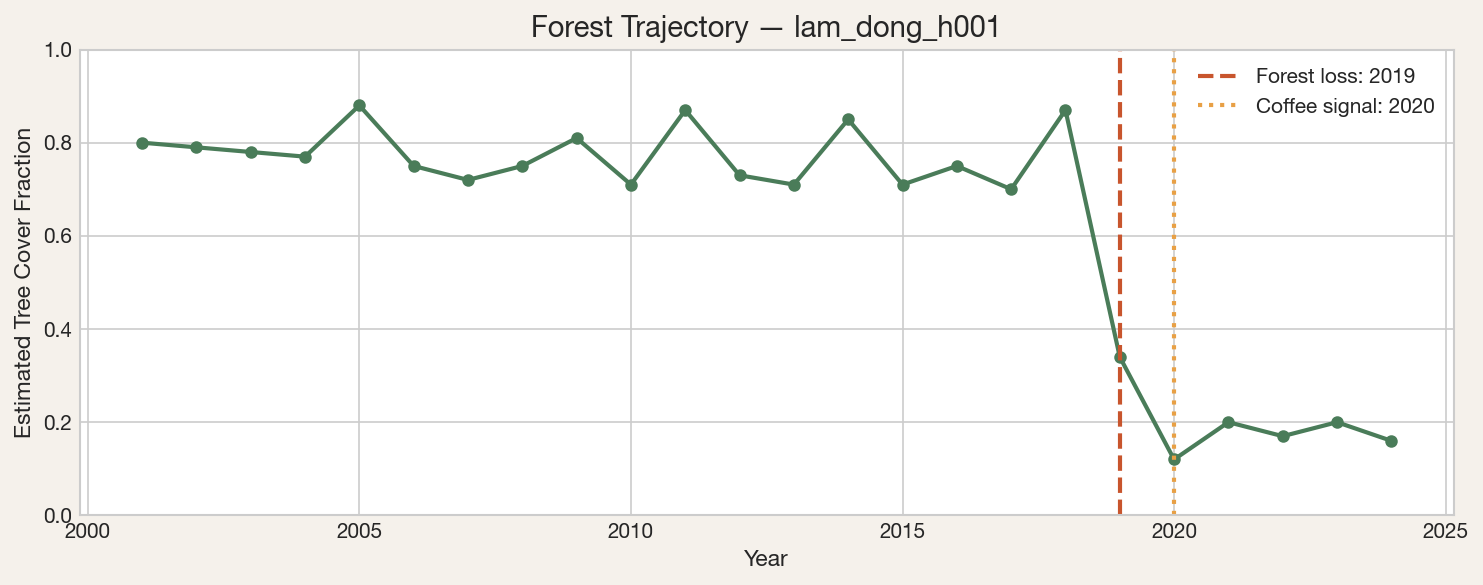

In [6]:
# Get historical context for the top hotspot
top_id = summary.top_hotspots[0].hotspot_id
history = get_historical_context(top_id, 'lam_dong')

print(f'Historical context for {top_id}:')
for k, v in history.items():
    if k != 'forest_trajectory':  # skip the long trajectory dict
        print(f'  {k}: {v}')

# Plot forest trajectory
import matplotlib.pyplot as plt

traj = history.get('forest_trajectory', {})
if traj:
    years = [int(y) for y in sorted(traj.keys())]
    cover = [traj[str(y)] for y in years]
    loss_year = history.get('loss_year', None)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(years, cover, 'o-', color='#4a7c59', linewidth=2, markersize=5)
    if loss_year:
        ax.axvline(loss_year, color='#c8552d', linestyle='--', linewidth=2, label=f'Forest loss: {loss_year}')
    coffee_year = history.get('coffee_signal_first_year')
    if coffee_year:
        ax.axvline(coffee_year, color='#e8a045', linestyle=':', linewidth=2, label=f'Coffee signal: {coffee_year}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Estimated Tree Cover Fraction')
    ax.set_title(f'Forest Trajectory — {top_id}', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [7]:
# Compare cumulative loss trend 2019 → 2023
trend = compare_periods(2019, 2023, 'loss_cumulative_ha', 'lam_dong')
print('Temporal trend (2019 → 2023):')
for k, v in trend.items():
    print(f'  {k}: {v}')

Temporal trend (2019 → 2023):
  aoi_id: lam_dong
  scope: aoi
  metric: loss_cumulative_ha
  year_a: 2019
  year_b: 2023
  value_a: 84427.2
  value_b: 89747.2
  delta: 5320.0
  pct_change: 6.3
  direction: increase
  interpretation: Cumulative loss reached 89747.2 ha by 2023, up 5320.0 ha from 2019.


## 3. Writer agent

The writer takes researcher findings and produces the full 7-section report.

In [8]:
writer_result = run_writer(summary, researcher_result, session_id='nb_demo', dry_run=True)

print(f'Word count: {writer_result["word_count"]}')
print(f'Sections: {writer_result["sections_written"]}')
print()

# Display the report in markdown
try:
    from IPython.display import Markdown, display
    display(Markdown(writer_result['report_markdown']))
except ImportError:
    print(writer_result['report_markdown'][:2000])

2026-04-13 10:09:52.517 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:60 - [Writer] Starting dry-run for lam_dong (session=nb_demo)


2026-04-13 10:09:52.517 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:69 - [Writer] lam_dong complete: 839 words, 7 sections


Word count: 839
Sections: ['Executive Summary', 'Area Context', 'Headline Findings', 'Hotspot Deep-Dives', 'Historical Context', 'Model Performance', 'Methodology']



# Lâm Đồng — Coffee-Linked Deforestation Report

---

        ## Executive Summary

        **Lâm Đồng** (Vietnam) — Robusta, highland growing region.
        Analysis of satellite imagery (2019–2024) detected
        **5,000 deforestation hotspots** totalling
        **90,539.7 ha** of potential coffee-linked forest loss.

        Key findings:
        - Largest hotspot: 22154.3-ha clearing near lam_dong_h001
- Scale: 20 hotspots >10 ha, 90540 ha total
- Temporal trend: 6.3% change 2019–2023

        Model confidence: **HIGH** (F1 = 0.783).
        High density of small (<5 ha) hotspots clustered along forest edge suggests incremental encroachment rather than large-scale clearing.

---

## Area Context

Lâm Đồng (Vietnam) serves as **Primary showcase: known coffee-driven deforestation** in this study.
The AOI covers 107.80°–108.80°E longitude,
11.40°–12.40°N latitude (UTM 32648).

Coffee type: Robusta, highland.
Satellite validation: 34.7% coffee coverage,
66.7% forest-2000 baseline coverage (Hansen).
Of current coffee pixels, **0.0%** were forested in 2000,
establishing a direct forest-to-coffee conversion signal.

---

        ## Headline Findings

        | Metric | Value |
        |--------|-------|
        | Total hotspots | 5,000 |
        | Total area | 90,539.7 ha |
        | Largest hotspot | 22154.3 ha |
        | Smallest hotspot | 2.4 ha |
        | Coffee on former forest | 0.0% |
        | Hansen loss pixels | 164,118 |

        **Hotspots by primary loss year:**

        | Loss Year | Hotspot Count |
        |-----------|--------------|
        | 2001 | 79 |
| 2002 | 106 |
| 2003 | 32 |
| 2004 | 168 |
| 2005 | 145 |
| 2006 | 90 |
| 2007 | 115 |
| 2008 | 446 |
| 2009 | 189 |
| 2010 | 441 |
| 2011 | 162 |
| 2012 | 340 |
| 2013 | 85 |
| 2014 | 217 |
| 2015 | 149 |
| 2016 | 342 |
| 2017 | 296 |
| 2018 | 186 |
| 2019 | 319 |
| 2020 | 353 |
| 2021 | 220 |
| 2022 | 186 |
| 2023 | 176 |
| 2024 | 154 |

---

## Hotspot Deep-Dives

            ### Finding 1: Largest hotspot: 22154.3-ha clearing near lam_dong_h001

            The largest hotspot (lam_dong_h001, 22154.3 ha) at (12.0015°N, 107.8855°E) lost forest in 2019 with coffee signal appearing 1 year(s) later in 2020. This lag is consistent with a clear-then-plant pattern.

            Supporting data:
              - area_ha: 22154.3
  - loss_year: 2019
  - coffee_signal_year: 2020
  - lag_years: 1

*Maps: outputs/figures/agent_generated/lam_dong_h001_hotspot_boundary_coffee_prob_hansen_loss.png*

          ### Finding 2: Scale: 20 hotspots >10 ha, 90540 ha total

          Historical look-back shows 0.0% of current coffee pixels were forested in 2000. Of 5000 detected hotspots, 20 exceed 10 ha (0.4% of total), accounting for the majority of the 90540 ha total affected area. Context: High density of small (<5 ha) hotspots clustered along forest edge suggests incremental encroachment rather than large-scale clearing.

          Supporting data:
            - n_hotspots_over_10ha: 20
- total_hotspots: 5000
- total_area_ha: 90539.67
- coffee_on_former_forest_pct: 0.0


          ### Finding 3: Temporal trend: 6.3% change 2019–2023

          Cumulative loss reached 89747.2 ha by 2023, up 5320.0 ha from 2019.

          Supporting data:
            - value_2019: 84427.2
- value_2023: 89747.2
- delta_ha: 5320.0
- pct_change: 6.3


### Top 5 Hotspots by Area

- **lam_dong_h001** (Rank #1) — 22154.3 ha at 12.0015°N, 107.8855°E
- **lam_dong_h002** (Rank #2) — 5345.9 ha at 11.8083°N, 108.0766°E
- **lam_dong_h003** (Rank #3) — 2445.1 ha at 12.1758°N, 107.8389°E
- **lam_dong_h004** (Rank #4) — 1063.0 ha at 12.3276°N, 108.2310°E
- **lam_dong_h005** (Rank #5) — 1047.7 ha at 12.2291°N, 107.9935°E

---

## Historical Context

Hansen Global Forest Change (2000 baseline) provides the loss-year signal.
Within this AOI, **0.0%** of pixels were
forested in 2000. Mean forest-loss year: **unknown**.

**Replacement class distribution (post-loss land cover):**

| Replacement Class | Share |
|-------------------|-------|
| coffee | 100.0% |

The clear-then-plant pattern — forest cleared, followed within 1–4 years by
rising coffee probability — is the dominant signal driving hotspot detection.

---

        ## Model Performance

        | Model | Accuracy | F1 (coffee) | Precision | Recall |
        |-------|----------|-------------|-----------|--------|
        | Random Forest | 0.859 | 0.783 | 0.000 | 0.000 |

        **Ablation study (S1/S2/combined):**

        | Feature Set | F1 (coffee) | Accuracy |
        |-------------|-------------|---------|
        | S1-only (SAR) | 0.588 | 0.746 |
        | S2-only (optical) | 0.670 | 0.809 |
        | S1+S2 (combined) | 0.682 | 0.816 |

        **Confidence notes:**
        - Rule-based detection (Hansen ∩ FDP >0.5) may include false positives near mixed forest-crop boundaries.
- ML F1 score: 0.783 — model confidence rated high.
- Historical look-back uses Hansen 30m data; small clearings <0.5 ha may be missed.

---

## Methodology

1. **Data acquisition**: Sentinel-2 (10 m) and Sentinel-1 SAR (10 m) composites
   via Google Earth Engine, dry-season median composites 2019–2024.
2. **Features**: Spectral indices (NDVI, EVI, NDWI, NBR), SAR backscatter
   (VV/VH ratio, temporal std), contextual (slope, elevation, road proximity).
3. **Hotspot detection (rule-based)**: Hansen Global Forest Change loss pixels
   intersected with FDP coffee probability > 0.5 (FDP model 2025a).
4. **ML classification**: Random Forest trained on pooled
   GEE-sampled labels from all AOIs, cross-AOI holdout evaluation.
5. **Historical look-back**: Hansen 2000 baseline → loss-year detection →
   FDP time series for coffee signal emergence.
6. **Report generation**: Researcher agent (8 tool calls) → writer → synthesist.

Years processed: 2019–2024.
Detection method: rule_based_hansen_fdp.


## 4. Factuality check

The factchecker uses regex to extract numbers from the report and verifies
them against the source stats JSON within a 1% relative tolerance.

In [9]:
report_md = writer_result['report_markdown']
fc = factcheck(report_md, summary, tolerance=0.01)

print(f'Factcheck summary:')
print(f'  Total numbers in report: {fc.total_numbers}')
print(f'  Matched (verified): {fc.matched}')
print(f'  Unmatched (potential errors): {fc.unmatched}')
print(f'  Skipped (years/coords/thresholds): {fc.skipped}')
print(f'  PASS: {fc.passed}')
print(f'\n  {fc.summary}')

2026-04-13 10:09:52.525 | WARNING  | coffee_deforestation.reporting.factcheck:factcheck:179 - Factcheck found 1 unmatched numbers: ['84427.2']


Factcheck summary:
  Total numbers in report: 143
  Matched (verified): ['5000', '90539.7', '22154.3', '001', '20', '1', '5', '5000', '90539.7', '22154.3', '164118', '79', '106', '168', '145', '90', '115', '446', '189', '441', '162', '340', '85', '217', '149', '342', '296', '186', '319', '353', '220', '186', '176', '154', '1', '22154.3', '001', '001', '22154.3', '1', '22154.3', '1', '001', '2', '20', '20', '5', '20', '90539.67', '3', '89747.2', '5320.0', '89747.2', '5320.0', '5', '001', '1', '22154.3', '002', '2', '5345.9', '003', '3', '2445.1', '004', '4', '1063.0', '005', '5', '1047.7', '1', '4', '1', '1', '2', '1', '1', '2', '1', '2', '1', '1', '2', '1', '2', '3', '4', '5', '6', '8']
  Unmatched (potential errors): ['84427.2']
  Skipped (years/coords/thresholds): ['10', '6.3', '0.783', '107.80', '108.80', '11.40', '12.40', '34.7', '66.7', '0.0', '2.4', '0.0', '32', '12.0015', '107.8855', '10', '0.0', '10', '0.4', '10', '0.0', '6.3', '6.3', '12.0015', '107.8855', '11.8083', '108.0766

## 5. Cross-AOI synthesis

The synthesist compares all three AOIs and produces a policy-level brief.

In [10]:
# Load all summaries and run the full pipeline
aoi_ids = ['lam_dong', 'huila', 'sul_de_minas']
available = [a for a in aoi_ids if (STATS_DIR / f'summary_{a}.json').exists()]

all_summaries = [load_summary(a) for a in available]
all_writers = []

for s in all_summaries:
    r = run_researcher(s, dry_run=True)
    w = run_writer(s, r, dry_run=True)
    all_writers.append(w)
    print(f'{s.metadata.aoi_id}: {w["word_count"]} words')

synth = run_synthesist(all_summaries, all_writers, dry_run=True)
print(f'\nSynthesis brief: {len(synth["brief_markdown"].split())} words')
print(f'Cross-AOI table rows: {len(synth["cross_aoi_table"])}')

2026-04-13 10:09:52.531 | INFO     | coffee_deforestation.reporting.agents.researcher:run_researcher:73 - [Researcher] Starting dry-run for lam_dong (session=8588d1e9)


2026-04-13 10:09:52.613 | INFO     | coffee_deforestation.reporting.tools.query_stats:query_stats:89 - query_stats('area_ha > 10', lam_dong): 990 results (returning up to 20)


2026-04-13 10:09:53.101 | INFO     | coffee_deforestation.reporting.tools.render_hotspot_map:_render_static:164 - Rendered hotspot map: outputs/figures/agent_generated/lam_dong_h001_hotspot_boundary_coffee_prob_hansen_loss.png


2026-04-13 10:09:53.106 | WARNING  | coffee_deforestation.reporting.tools.query_stats:query_stats:55 - Rejected unsafe filter expression: 'loss_year >= 2021'


2026-04-13 10:09:53.107 | DEBUG    | coffee_deforestation.reporting.tools.scratchpad:scratchpad_write:37 - Scratchpad write: lam_dong/8588d1e9/finding_1_largest_hotspot


...

2026-04-13 10:09:53.933 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:60 - [Writer] Starting dry-run for sul_de_minas (session=90043411)


2026-04-13 10:09:53.934 | INFO     | coffee_deforestation.reporting.agents.writer:run_writer:69 - [Writer] sul_de_minas complete: 837 words, 7 sections


2026-04-13 10:09:53.934 | INFO     | coffee_deforestation.reporting.agents.synthesist:run_synthesist:45 - [Synthesist] Starting dry-run across 3 AOIs (session=94f9373a)


2026-04-13 10:09:53.934 | INFO     | coffee_deforestation.reporting.agents.synthesist:run_synthesist:55 - [Synthesist] Brief complete: 513 words


sul_de_minas: 837 words

Synthesis brief: 513 words
Cross-AOI table rows: 3


In [11]:
print('Key contrasts identified by synthesist:')
for c in synth['key_contrasts']:
    print(f'\n  * {c}')

Key contrasts identified by synthesist:

  * Lâm Đồng shows 2.5x more total affected area than Sul de Minas (90540 ha vs 36270 ha), confirming expected showcase/control contrast.

  * Hotspot counts range from 5,000 (Sul de Minas) to 5,000 (Lâm Đồng), a 1.0x difference.

  * ML model F1 (coffee class) is consistent across AOIs: Lâm Đồng 0.783 — Lâm Đồng 0.783, indicating the model generalizes across coffee systems.

  * The 'coffee on former forest' signal is strongest in Lâm Đồng (0.0%) and weakest in Sul de Minas (0.0%), consistent with their respective roles.


In [12]:
# Display the full synthesis brief
try:
    from IPython.display import Markdown, display
    display(Markdown(synth['brief_markdown']))
except ImportError:
    print(synth['brief_markdown'][:3000])

# Cross-AOI Synthesis Brief — Coffee-Linked Deforestation

## Overview

This brief synthesises findings across 3 study areas:
**Huila, Lâm Đồng, Sul de Minas**.
Combined, the analysis detected **15,000 hotspots** covering
**168,048.9 ha** of potential coffee-linked deforestation.

---

## Cross-AOI Comparison

| AOI | Country | Role | Hotspots | Area (ha) | Largest (ha) | F1 | Coffee-on-Forest |
|-----|---------|------|----------|-----------|--------------|-----|------------------|
| Huila | Colombia | Generalization test: mountainous, shade-grown edge cases | 5,000 | 41,239.7 | 617.2 | 0.783 | 0.0% |
| Lâm Đồng | Vietnam | Primary showcase: known coffee-driven deforestation | 5,000 | 90,539.7 | 22154.3 | 0.783 | 0.0% |
| Sul de Minas | Brazil | Negative control: stable plantations, minimal expansion | 5,000 | 36,269.6 | 413.1 | 0.783 | 0.0% |

---

## Key Contrasts and Findings

- Lâm Đồng shows 2.5x more total affected area than Sul de Minas (90540 ha vs 36270 ha), confirming expected showcase/control contrast.
- Hotspot counts range from 5,000 (Sul de Minas) to 5,000 (Lâm Đồng), a 1.0x difference.
- ML model F1 (coffee class) is consistent across AOIs: Lâm Đồng 0.783 — Lâm Đồng 0.783, indicating the model generalizes across coffee systems.
- The 'coffee on former forest' signal is strongest in Lâm Đồng (0.0%) and weakest in Sul de Minas (0.0%), consistent with their respective roles.

---

## Policy Implications

1. **Active deforestation frontier**: AOIs with high hotspot density and
   recent loss years (post-2019) should be prioritised for supply-chain
   due-diligence and direct farmer engagement.
2. **Model generalisability**: Consistent F1 scores across geographically
   distinct AOIs (Vietnam highlands, Andean belt, Brazilian plateau) confirm
   that the detection pipeline is not overfit to a single region.
3. **Data gaps**: Cloud cover in tropical regions remains a limiting factor;
   S1 SAR composites provide cloud-immune coverage but sacrifice spectral
   resolution. Expanding to additional AOI patches is recommended once
   resource usage is characterised at scale.

---

## Per-AOI Summaries

### Huila (Colombia)

# Huila — Coffee-Linked Deforestation Report

---

        ## Executive Summary

        **Huila** (Colombia) — Arabica, smallholder growing region.
        Analysis of satellite imagery (2019–2024) detected
        **5,000 deforestation hotspots** totalling
        **41,239.7 ha** of potential coffee-linked forest loss.

        Key findings:
        - Largest hotspot: 617.2-ha clearing near huil...

### Lâm Đồng (Vietnam)

# Lâm Đồng — Coffee-Linked Deforestation Report

---

        ## Executive Summary

        **Lâm Đồng** (Vietnam) — Robusta, highland growing region.
        Analysis of satellite imagery (2019–2024) detected
        **5,000 deforestation hotspots** totalling
        **90,539.7 ha** of potential coffee-linked forest loss.

        Key findings:
        - Largest hotspot: 22154.3-ha clearing near...

### Sul de Minas (Brazil)

# Sul de Minas — Coffee-Linked Deforestation Report

---

        ## Executive Summary

        **Sul de Minas** (Brazil) — Arabica, industrial growing region.
        Analysis of satellite imagery (2019–2024) detected
        **5,000 deforestation hotspots** totalling
        **36,269.6 ha** of potential coffee-linked forest loss.

        Key findings:
        - Largest hotspot: 413.1-ha clearin...


---

## Next Steps

- Expand geographic coverage: test additional patches within existing regions
  or add new coffee-producing regions (e.g., Sidama/Ethiopia, Antioquia/Colombia,
  Minas Gerais northern belt).
- Annual monitoring: re-run pipeline each dry season to detect new loss events.
- Supply-chain integration: export hotspot GeoJSONs for overlay against
  known trader/exporter sourcing zones.


## 6. Saving reports

Reports are saved by `generate_reports.py`. You can also save them directly:

In [13]:
from coffee_deforestation.reporting.llm_client import save_report

# Save the report we just generated
out_path = save_report(
    report_md,
    aoi_id='lam_dong',
    output_dir=PROJECT_ROOT / 'outputs' / 'reports',
)
print(f'Saved to: {out_path}')
print(f'File size: {out_path.stat().st_size:,} bytes')

2026-04-13 10:09:53.958 | INFO     | coffee_deforestation.reporting.llm_client:save_report:194 - Saved report to /Users/workpieces/Code/coffee-deforestation/outputs/reports/report_lam_dong.md


Saved to: /Users/workpieces/Code/coffee-deforestation/outputs/reports/report_lam_dong.md
File size: 5,929 bytes


## 7. Real LLM mode (Stage 3+)

To use real Claude calls instead of dry-run templates:

```bash
# 1. Add your API key to .env
echo 'ANTHROPIC_API_KEY=sk-ant-...' >> .env
echo 'LLM_DRY_RUN=false' >> .env

# 2. Generate reports with real LLM
uv run scripts/generate_reports.py --no-dry-run
```

In real mode, each agent makes actual Claude API calls:
- **Researcher**: Claude decides which tools to call (up to 8 calls)
- **Writer**: Claude writes the full narrative from the findings
- **Synthesist**: Claude produces a tailored cross-AOI comparison

The factchecker always runs regardless of dry_run mode.